In [ ]:
# install dependencies
!pip install transformers datasets torch scikit-learn matplotlib seaborn arxiv -q
!pip install 'accelerate>=1.1.0'

In [2]:
# imports
import arxiv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
categories = {
    "cs.AI": "Artificial Intelligence",
    "cs.AR": "Hardware Architecture",
    "cs.CC": "Computational Complexity",
    "cs.CE": "Computational Engineering, Finance, and Science",
    "cs.CG": "Computational Geometry",
    "cs.CL": "Computation and Language",
    "cs.CR": "Cryptography and Security",
    "cs.CV": "Computer Vision and Pattern Recognition",
    "cs.CY": "Computers and Society",
    "cs.DB": "Databases",
    "cs.DC": "Distributed, Parallel, and Cluster Computing",
    "cs.DL": "Digital Libraries",
    "cs.DM": "Discrete Mathematics",
    "cs.DS": "Data Structures and Algorithms",
    "cs.ET": "Emerging Technologies",
    "cs.FL": "Formal Languages and Automata Theory",
    "cs.GL": "General Literature",
    "cs.GR": "Graphics",
    "cs.GT": "Computer Science and Game Theory",
    "cs.HC": "Human-Computer Interaction",
    "cs.IR": "Information Retrieval",
    "cs.IT": "Information Theory",
    "cs.LG": "Machine Learning",
    "cs.LO": "Logic in Computer Science",
    "cs.MA": "Multiagent Systems",
    "cs.MM": "Multimedia",
    "cs.MS": "Mathematical Software",
    "cs.NA": "Numerical Analysis",
    "cs.NE": "Neural and Evolutionary Computing",
    "cs.NI": "Networking and Internet Architecture",
    "cs.OH": "Other Computer Science",
    "cs.OS": "Operating Systems",
    "cs.PF": "Performance",
    "cs.PL": "Programming Languages",
    "cs.RO": "Robotics",
    "cs.SC": "Symbolic Computation",
    "cs.SD": "Sound",
    "cs.SE": "Software Engineering",
    "cs.SI": "Social and Information Networks"
}


In [ ]:
# avoid pagination by staying at 100 papers per category...
# https://lukasschwab.me/arxiv.py/arxiv.html
import time

PAPERS_PER_CATEGORY = 100 # 100 = 1 API page only -> no rate limit issues
# Increase to 500 for final model maybe?

client = arxiv.Client(page_size=100,delay_seconds=10,num_retries=2)

def collect_abstracts(categories, papers_per_cat):
    records = []
    for cat_code, cat_name in categories.items():
        print(f"Fetching {papers_per_cat} papers for: {cat_name} ({cat_code})...")
        success = False
        attempts = 0
        while not success and attempts < 2:
            try:
                search = arxiv.Search(
                    query=f"cat:{cat_code}",
                    max_results=papers_per_cat,
                    sort_by=arxiv.SortCriterion.Relevance # changed this to relevance
                )
                count = 0
                for result in client.results(search):
                    records.append({
                        "category_code": cat_code,
                        "category_name": cat_name,
                        "title": result.title,
                        "abstract": result.summary,
                    })
                    count += 1
                print(f"Got {count} papers.")
                success = True
            except Exception as e:
                attempts += 1
                wait = 10 * attempts  # changed to 10sec for optimization (prev was 30)
                print(f"Error ({e}). Waiting {wait}s before retry {attempts}/3...")
                time.sleep(wait)
        time.sleep(5)  # 5 second pause between every category otherwise rejects request

    return pd.DataFrame(records)

df_raw = collect_abstracts(categories, PAPERS_PER_CATEGORY)
print(f"\nTotal papers collected: {len(df_raw)}")
df_raw.head(3)

In [ ]:
# save raw data to CSV
df_raw.to_csv("baseline/arxiv_cs_abstracts_raw.csv", index=False)
print("Saved to arxiv_cs_abstracts_raw.csv")

# Later, to reload without re-fetching:
# df_raw = pd.read_csv("arxiv_cs_abstracts_raw.csv")

In [7]:
# Adding helper block to extract pandas df from csv to prevent regeneration problem
df_raw = pd.read_csv('100_arxiv_cs_abstracts_raw.csv')

In [8]:
# Exploratory Data Analysis (EDA) !!
# basic stats
print("=== Dataset Overview ===")
print(f"Total samples:{len(df_raw)}")
print(f"Columns:{list(df_raw.columns)}")
print(f"Missing abstracts:{df_raw['abstract'].isnull().sum()}")
print(f"Duplicate entries:{df_raw.duplicated(subset='abstract').sum()}")
print("=== Class Distribution ===")
print(df_raw['category_name'].value_counts())

=== Dataset Overview ===
Total samples:3800
Columns:['category_code', 'category_name', 'title', 'abstract']
Missing abstracts:0
Duplicate entries:567
=== Class Distribution ===
category_name
Artificial Intelligence                            100
Hardware Architecture                              100
Computational Complexity                           100
Computational Engineering, Finance, and Science    100
Computational Geometry                             100
Computation and Language                           100
Cryptography and Security                          100
Computer Vision and Pattern Recognition            100
Computers and Society                              100
Databases                                          100
Distributed, Parallel, and Cluster Computing       100
Digital Libraries                                  100
Discrete Mathematics                               100
Data Structures and Algorithms                     100
Emerging Technologies                  

FileNotFoundError: [Errno 2] No such file or directory: 'baseline/class_distribution.png'

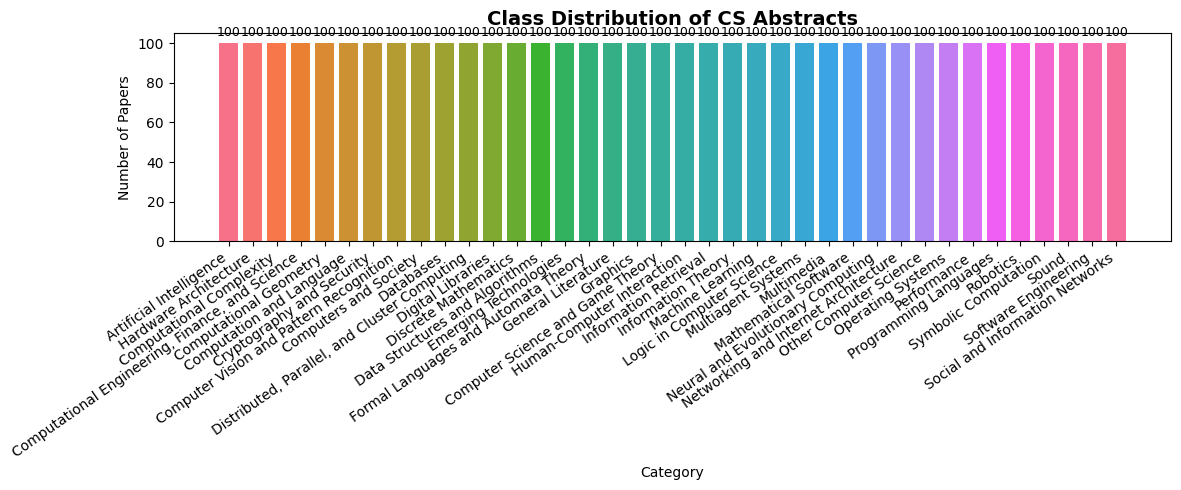

In [9]:
# class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 5))
counts = df_raw['category_name'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette("husl", len(counts)))
ax.set_title("Class Distribution of CS Abstracts", fontsize=14, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Number of Papers")
ax.set_xticklabels(counts.index, rotation=35, ha='right')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("baseline/class_distribution.png", dpi=150)
plt.show()
print("Saved class_distribution.png!")

=== Abstract Length Stats (in words) ===
count    3800.0
mean      161.7
std        56.9
min         3.0
25%       121.0
50%       160.0
75%       201.0
max       385.0
Name: abstract_length, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'baseline/abstract_lengths.png'

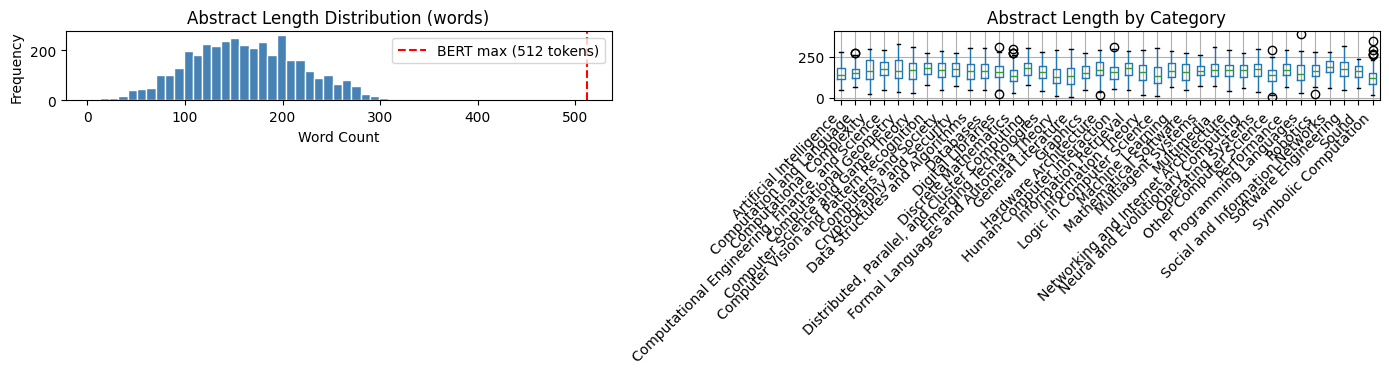

In [10]:
# abstract length distribution
df_raw['abstract_length'] = df_raw['abstract'].apply(lambda x: len(x.split()))

print("=== Abstract Length Stats (in words) ===")
print(df_raw['abstract_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall distribution
axes[0].hist(df_raw['abstract_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
axes[0].set_title("Abstract Length Distribution (words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# by category (box plot)
df_raw.boxplot(column='abstract_length', by='category_name', ax=axes[1])
axes[1].set_title("Abstract Length by Category")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.suptitle("")
plt.tight_layout()
plt.savefig("baseline/abstract_lengths.png", dpi=150)
plt.show()
print("Saved abstract_lengths.png")

In [11]:
# text cleaning
import re
def clean_abstract(text):
    text = re.sub(r'\n', ' ', text) # remove newlines
    text = re.sub(r'\s+', ' ', text)  # collapse whitespace
    text = re.sub(r'[^\x00-\x7F]+', '', text) # remove non-ASCII
    return text.strip()

df = df_raw.copy()
df = df.drop_duplicates(subset='abstract')  # drop duplicates
df = df.dropna(subset=['abstract']) # drop missing
df['abstract_clean'] = df['abstract'].apply(clean_abstract)
print(f"After cleaning: {len(df)} samples (removed {len(df_raw) - len(df)})")

After cleaning: 3233 samples (removed 567)


In [12]:
# encode category labels as integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['category_code'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls} ({categories[cls]})")

Label mapping:
  0 → cs.AI (Artificial Intelligence)
  1 → cs.AR (Hardware Architecture)
  2 → cs.CC (Computational Complexity)
  3 → cs.CE (Computational Engineering, Finance, and Science)
  4 → cs.CG (Computational Geometry)
  5 → cs.CL (Computation and Language)
  6 → cs.CR (Cryptography and Security)
  7 → cs.CV (Computer Vision and Pattern Recognition)
  8 → cs.CY (Computers and Society)
  9 → cs.DB (Databases)
  10 → cs.DC (Distributed, Parallel, and Cluster Computing)
  11 → cs.DL (Digital Libraries)
  12 → cs.DM (Discrete Mathematics)
  13 → cs.DS (Data Structures and Algorithms)
  14 → cs.ET (Emerging Technologies)
  15 → cs.FL (Formal Languages and Automata Theory)
  16 → cs.GL (General Literature)
  17 → cs.GR (Graphics)
  18 → cs.GT (Computer Science and Game Theory)
  19 → cs.HC (Human-Computer Interaction)
  20 → cs.IR (Information Retrieval)
  21 → cs.IT (Information Theory)
  22 → cs.LG (Machine Learning)
  23 → cs.LO (Logic in Computer Science)
  24 → cs.MA (Multiagent

In [13]:
# 80/10/10 split
train_df, temp_df = train_test_split(df, test_size=0.2,
                                      stratify=df['label'], random_state=1)
val_df, test_df   = train_test_split(temp_df, test_size=0.5,
                                      stratify=temp_df['label'], random_state=1)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


dist_df = pd.DataFrame({
    "Train": train_df['category_name'].value_counts(normalize=True),
    "Val":   val_df['category_name'].value_counts(normalize=True),
    "Test":  test_df['category_name'].value_counts(normalize=True),
}).fillna(0)

print(dist_df)

Train: 2586 | Val: 323 | Test: 324
                                                    Train       Val      Test
category_name                                                                
Artificial Intelligence                          0.030936  0.030960  0.030864
Computation and Language                         0.027456  0.027864  0.027778
Computational Complexity                         0.030936  0.030960  0.030864
Computational Engineering, Finance, and Science  0.030936  0.030960  0.030864
Computational Geometry                           0.029776  0.030960  0.030864
Computer Science and Game Theory                 0.027456  0.027864  0.027778
Computer Vision and Pattern Recognition          0.025909  0.024768  0.027778
Computers and Society                            0.026295  0.024768  0.027778
Cryptography and Security                        0.028616  0.027864  0.027778
Data Structures and Algorithms                   0.020882  0.021672  0.018519
Databases                    

In [14]:
dist_df.plot(kind='bar', figsize=(10,6))

plt.title("Category Distribution Across Splits")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Dataset", loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=3)
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=300)
plt.close()

In [15]:
# tokenize using BERT's tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# check a sample tokenization
sample = df['abstract_clean'].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=512)
print(f"Sample abstract (first 100 chars): {sample[:100]}...")
print(f"Number of tokens: {len(tokens['input_ids'])}")
print(f"Token IDs (first 20): {tokens['input_ids'][:20]}")

Sample abstract (first 100 chars): Ramp metering that uses traffic signals to regulate vehicle flows from the on-ramps has been widely ...
Number of tokens: 235
Token IDs (first 20): [101, 13276, 8316, 2075, 2008, 3594, 4026, 7755, 2000, 15176, 4316, 6223, 2013, 1996, 2006, 1011, 24943, 2038, 2042, 4235]


In [16]:
# tokenize the full dataset
def tokenize_batch(texts, tokenizer, max_length=256):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,  # 256 is a good balance of speed vs coverage
        return_tensors='pt'
    )

print("Tokenizing training set...")
train_encodings = tokenize_batch(train_df['abstract_clean'], tokenizer)
print("Tokenizing validation set...")
val_encodings   = tokenize_batch(val_df['abstract_clean'], tokenizer)
print("Tokenizing test set...")
test_encodings  = tokenize_batch(test_df['abstract_clean'], tokenizer)

print("Tokenization complete!")
print(f"Input shape (train): {train_encodings['input_ids'].shape}")

Tokenizing training set...
Tokenizing validation set...
Tokenizing test set...
Tokenization complete!
Input shape (train): torch.Size([2586, 256])


In [17]:
import torch
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())
print(torch.device("mps" if torch.backends.mps.is_available() else "cpu")) # I don't remember whose not on Mac but if someone has CUDA alter this

False
False
cpu


In [21]:
# https://huggingface.co/transformers/v4.2.2/training.html
# BERT training frozen encoder + classification layer
from torch.utils.data import Dataset
from transformers import (BertForSequenceClassification, Trainer,TrainingArguments)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import EarlyStoppingCallback

# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class CSAbstractDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = CSAbstractDataset(train_encodings, train_df["label"].tolist())
val_dataset   = CSAbstractDataset(val_encodings, val_df["label"].tolist())
test_dataset  = CSAbstractDataset(test_encodings, test_df["label"].tolist())

model = BertForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=len(le.classes_))
for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir="./bert_frozen_encoder",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=50,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,  
    weight_decay=0.01,
)

# Citation for compute_metric function: https://huggingface.co/transformers/v4.2.2/training.html
def compute_metrics(pred):
    raw, labels = pred
    preds = np.argmax(raw, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1,"precision": precision, "recall": recall}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,   # use validation here
    compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=7)]
)

trainer.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12602.54it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,3.631307,3.580830,0.037152,0.005802,0.003309,0.032456
2,3.556293,3.522852,0.083591,0.030608,0.024752,0.075731
3,3.518423,3.479384,0.080495,0.039885,0.046408,0.071199
4,3.470456,3.457841,0.074303,0.032072,0.043733,0.066740
5,3.440528,3.438842,0.083591,0.049526,0.061153,0.081287
6,3.414014,3.398980,0.120743,0.063368,0.068467,0.113231
7,3.402031,3.387105,0.086687,0.062468,0.090574,0.079898
8,3.369857,3.360256,0.136223,0.077265,0.096397,0.125585
9,3.348872,3.344351,0.148607,0.091230,0.092263,0.138189
10,3.338269,3.321160,0.145511,0.095033,0.115110,0.135819


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.70s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

TrainOutput(global_step=3726, training_loss=3.322142809357492, metrics={'train_runtime': 279.501, 'train_samples_per_second': 462.61, 'train_steps_per_second': 28.98, 'total_flos': 7827188835981312.0, 'train_loss': 3.322142809357492, 'epoch': 23.0})

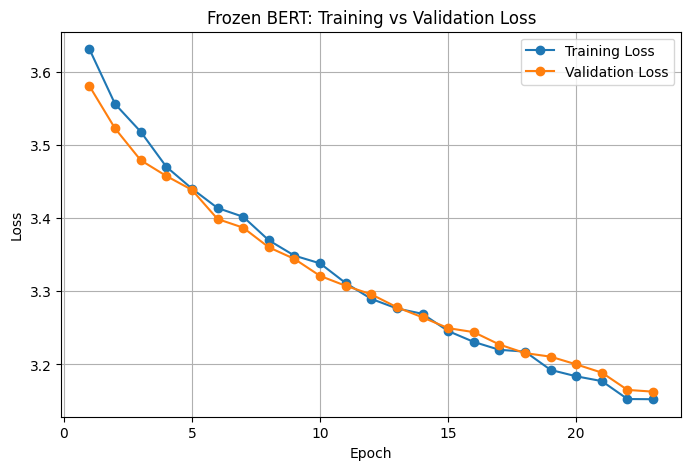

In [22]:
# Figure for validation + training loss, overfitting check!
log_df = pd.DataFrame(trainer.state.log_history)
log_df = log_df[log_df["epoch"].notna()].copy()
train_loss_df = log_df[log_df["loss"].notna()][["epoch", "loss"]].copy()
val_loss_df = log_df[log_df["eval_loss"].notna()][["epoch", "eval_loss"]].copy()
plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen BERT: Training vs Validation Loss")
plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o", label="Training Loss")
plt.plot(val_loss_df["epoch"], val_loss_df["eval_loss"], marker="o", label="Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

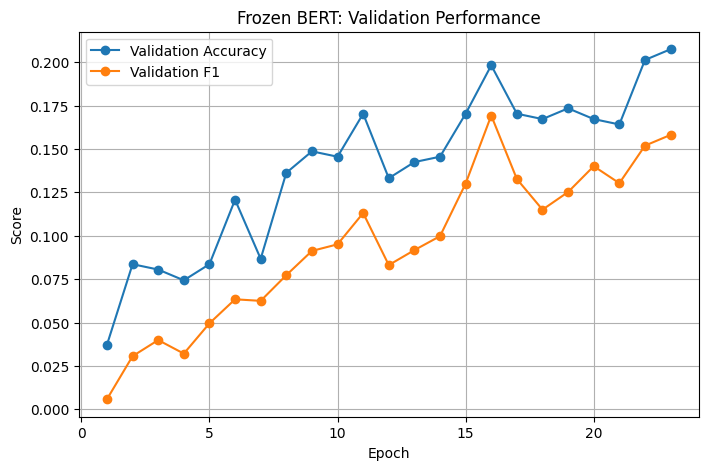

In [23]:
val_metrics_df = log_df[log_df["eval_accuracy"].notna()][["epoch", "eval_accuracy", "eval_f1"]].copy()
plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Frozen BERT: Validation Performance")
plt.plot(val_metrics_df["epoch"], val_metrics_df["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(val_metrics_df["epoch"], val_metrics_df["eval_f1"], marker="o", label="Validation F1")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# BERT fine tuning (encoder + classification head)
fine_tune_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_),
)

fine_tune_training_args = TrainingArguments(
    output_dir="./bert_fine_tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=50,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,  
    weight_decay=0.01
)

fine_tune_trainer = Trainer(
    model=fine_tune_model,
    args=fine_tune_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

fine_tune_trainer.train()

fine_tune_log_df = pd.DataFrame(fine_tune_trainer.state.log_history)
fine_tune_log_df = fine_tune_log_df[fine_tune_log_df["epoch"].notna()].copy()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13236.49it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,3.261517,2.717358,0.297214,0.234464,0.317464,0.289035
2,2.446410,2.227166,0.399381,0.341451,0.369435,0.386477
3,1.844479,1.925784,0.489164,0.459645,0.530271,0.479574
4,1.361613,1.781618,0.495356,0.455867,0.457306,0.484921
5,0.971628,1.799847,0.495356,0.464301,0.483404,0.482101
6,0.656706,1.906931,0.498452,0.465033,0.484516,0.483970
7,0.419840,1.922487,0.495356,0.474121,0.488915,0.485015
8,0.271524,2.141258,0.492260,0.467360,0.484993,0.481986
9,0.169029,2.310088,0.495356,0.485500,0.516998,0.490288
10,0.089916,2.461025,0.492260,0.480161,0.508381,0.487772


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.81s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

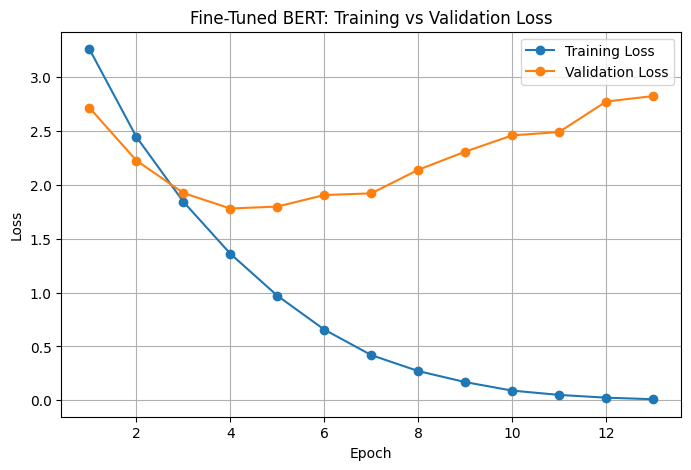

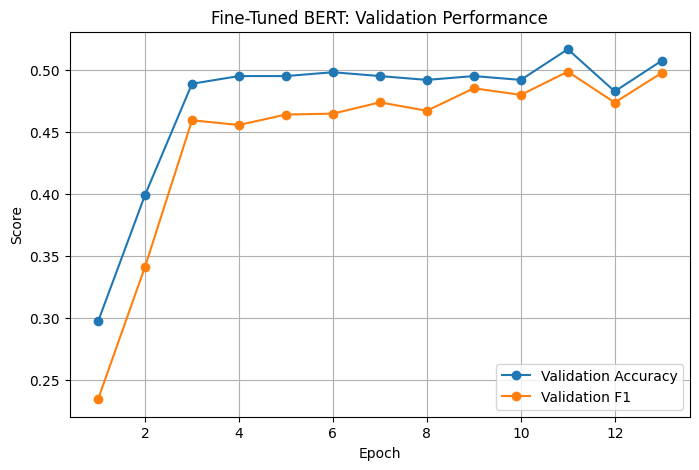

In [27]:
fine_tune_train_loss_df = fine_tune_log_df[fine_tune_log_df["loss"].notna()][["epoch", "loss"]].copy()
fine_tune_val_loss_df = fine_tune_log_df[fine_tune_log_df["eval_loss"].notna()][["epoch", "eval_loss"]].copy()

plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned BERT: Training vs Validation Loss")
plt.plot(fine_tune_train_loss_df["epoch"], fine_tune_train_loss_df["loss"], marker="o", label="Training Loss")
plt.plot(fine_tune_val_loss_df["epoch"], fine_tune_val_loss_df["eval_loss"], marker="o", label="Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

fine_tune_val_metrics_df = fine_tune_log_df[fine_tune_log_df["eval_accuracy"].notna()][["epoch", "eval_accuracy", "eval_f1"]].copy()

plt.figure(figsize=(8, 5))
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Fine-Tuned BERT: Validation Performance")
plt.plot(fine_tune_val_metrics_df["epoch"], fine_tune_val_metrics_df["eval_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(fine_tune_val_metrics_df["epoch"], fine_tune_val_metrics_df["eval_f1"], marker="o", label="Validation F1")
plt.legend()
plt.grid(True)
plt.show()


=== Frozen BERT — Test Set ===
Accuracy: 0.1327
              precision    recall  f1-score   support

       cs.AI       0.00      0.00      0.00        10
       cs.AR       0.07      0.10      0.08        10
       cs.CC       0.20      0.20      0.20        10
       cs.CE       0.07      0.40      0.12        10
       cs.CG       0.14      0.10      0.12        10
       cs.CL       0.00      0.00      0.00         9
       cs.CR       0.07      0.22      0.11         9
       cs.CV       0.25      0.22      0.24         9
       cs.CY       0.08      0.33      0.12         9
       cs.DB       0.20      0.10      0.13        10
       cs.DC       0.00      0.00      0.00         9
       cs.DL       0.40      0.20      0.27        10
       cs.DM       0.00      0.00      0.00         9
       cs.DS       0.00      0.00      0.00         6
       cs.ET       0.11      0.10      0.11        10
       cs.FL       0.14      0.11      0.12         9
       cs.GL       0.17      0.7

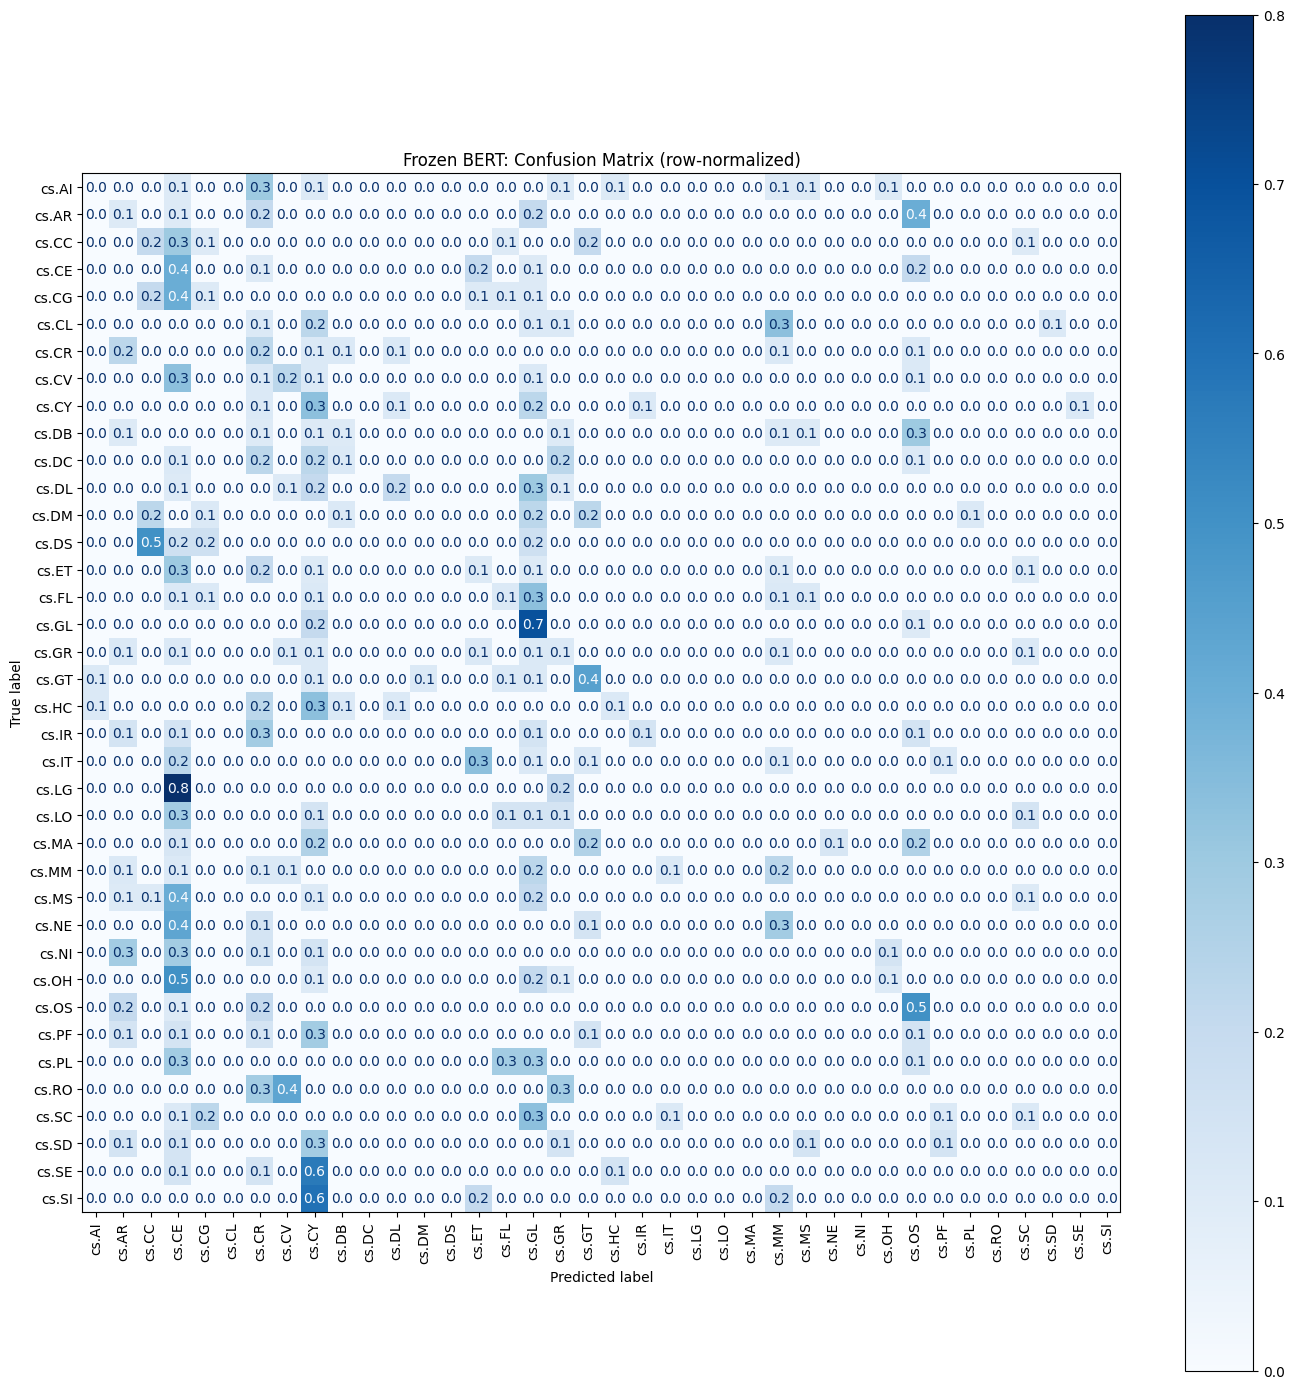


=== Fine-Tuned BERT — Test Set ===
Accuracy: 0.4630
              precision    recall  f1-score   support

       cs.AI       0.00      0.00      0.00        10
       cs.AR       0.75      0.30      0.43        10
       cs.CC       0.33      0.40      0.36        10
       cs.CE       0.30      0.30      0.30        10
       cs.CG       0.58      0.70      0.64        10
       cs.CL       1.00      0.44      0.62         9
       cs.CR       0.30      0.33      0.32         9
       cs.CV       0.45      0.56      0.50         9
       cs.CY       0.38      0.33      0.35         9
       cs.DB       0.56      0.90      0.69        10
       cs.DC       0.15      0.22      0.18         9
       cs.DL       1.00      0.90      0.95        10
       cs.DM       0.44      0.44      0.44         9
       cs.DS       0.29      0.33      0.31         6
       cs.ET       0.73      0.80      0.76        10
       cs.FL       0.67      0.44      0.53         9
       cs.GL       0.67     

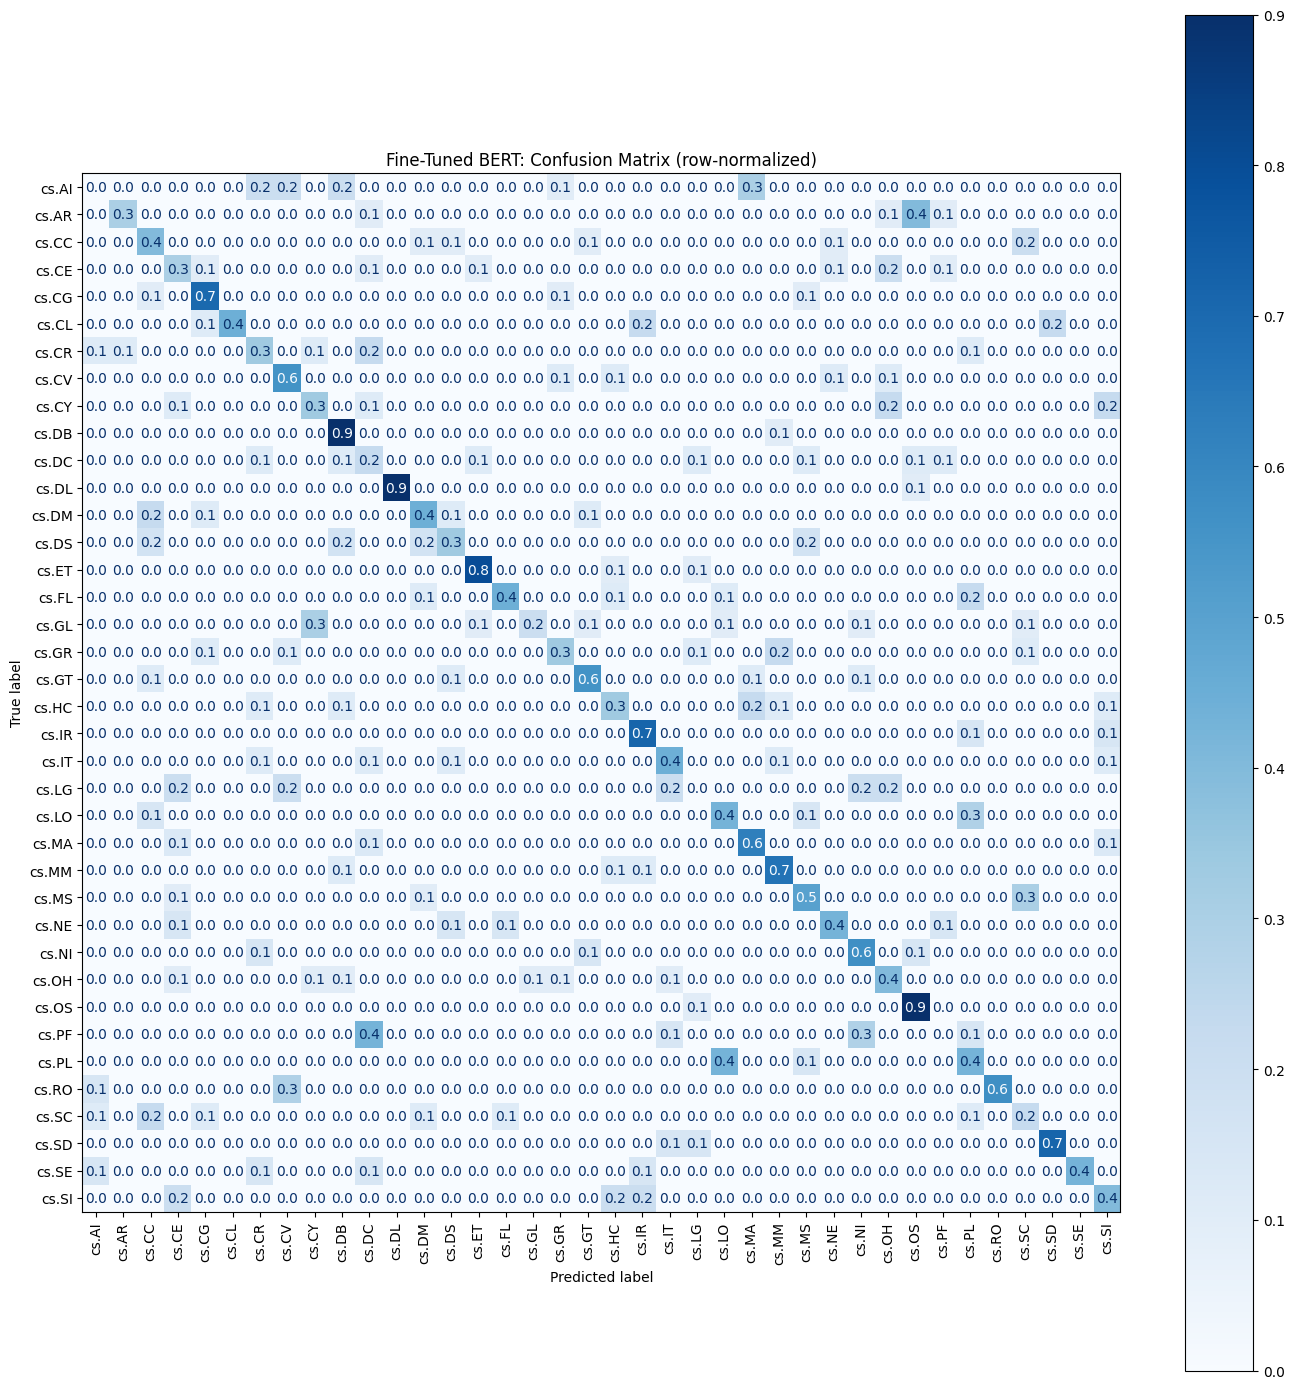

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_cm(trainer, test_dataset, label_encoder, title, save_path):
    pred_output = trainer.predict(test_dataset)
    y_pred = np.argmax(pred_output.predictions, axis=-1)
    y_true = pred_output.label_ids
    
    print(f"\n=== {title} — Test Set ===")
    print(f"Accuracy: {(y_pred == y_true).mean():.4f}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_encoder.classes_)), normalize='true')
    fig, ax = plt.subplots(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap='Blues', values_format='.1f')
    ax.set_title(f"{title}: Confusion Matrix (row-normalized)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return y_true, y_pred

frozen_true, frozen_pred = plot_cm(trainer, test_dataset, le, "Frozen BERT", "confusion_frozen.png")
ft_true, ft_pred = plot_cm(fine_tune_trainer, test_dataset, le, "Fine-Tuned BERT", "confusion_fine_tuned.png")